1) LOOK AT THE DATA

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
uploaded = files.upload()

Saving Revenue Analyst Assessment.xlsx to Revenue Analyst Assessment.xlsx


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename, sheet_name='Raw Data')

In [ ]:
print(df.shape)

(84897, 13)


In [ ]:
print(df.dtypes)

Service Departure Date         datetime64[ns]
Rail Period                            object
Rail Week Week                         object
Route Name                             object
Service                                object
Stock Type                             object
Total Capacity                          int64
Day Of Week (Short)                    object
Service Departure Hour                  int64
Max Load                              float64
Max Count                               int64
Count of Overcrowded Trains             int64
Overcrowded Minutes                     int64
dtype: object


In [ ]:
df.head()

,Service Departure Date,Rail Period,Rail Week Week,Route Name,Service,Stock Type,Total Capacity,Day Of Week (Short),Service Departure Hour,Max Load,Max Count,Count of Overcrowded Trains,Overcrowded Minutes
0,2022-01-18,2022/P11,2022/W43,London-Midlands,21:46 WVH-EUS,390,362,TUE,21,0.104972,38,0,0
1,2022-01-18,2022/P11,2022/W43,Manchester,21:15 MAN-EUS,390,362,TUE,21,0.132597,48,0,0
2,2022-01-18,2022/P11,2022/W43,Anglo-Scot,18:52 EDB-EUS,390,362,TUE,18,0.154696,56,0,0
3,2022-01-18,2022/P11,2022/W43,Anglo-Scot,05:30 BHM-BPN,10VyHStd,460,TUE,5,0.030435,14,0,0
4,2022-01-18,2022/P11,2022/W43,Manchester,06:16 EUS-MAN,390,362,TUE,6,0.251381,91,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84897 entries, 0 to 84896
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Service Departure Date       84897 non-null  datetime64[ns]
 1   Rail Period                  84897 non-null  object        
 2   Rail Week Week               84897 non-null  object        
 3   Route Name                   84897 non-null  object        
 4   Service                      84897 non-null  object        
 5   Stock Type                   84897 non-null  object        
 6   Total Capacity               84897 non-null  int64         
 7   Day Of Week (Short)          84897 non-null  object        
 8   Service Departure Hour       84897 non-null  int64         
 9   Max Load                     84897 non-null  float64       
 10  Max Count                    84897 non-null  int64         
 11  Count of Overcrowded Trains  84897 non-nu

2) VALIDATE DATA

In [ ]:
print("Routes:\n", df["Route Name"].unique(), "\n")

Routes:
 ['London-Midlands' 'Manchester' 'Anglo-Scot'] 



In [ ]:
print("Stock Types:\n", df["Stock Type"].unique(), "\n")

Stock Types:
 ['390' '10VyHStd' '391' 390 '5VyHyStd'] 



In [ ]:
print("Days of week:\n", df["Day Of Week (Short)"].unique(), "\n")

Days of week:
 ['TUE' 'WED' 'THU' 'FRI' 'SAT' 'SUN' 'MON'] 



In [ ]:
print("Earliest date:", df["Service Departure Date"].min())

Earliest date: 2022-01-18 00:00:00


In [ ]:
print("Latest date:", df["Service Departure Date"].max())

Latest date: 2024-01-17 00:00:00


In [ ]:
df[["Total Capacity", "Max Load", "Max Count", "Count of Overcrowded Trains", "Overcrowded Minutes"]].describe()

,Total Capacity,Max Load,Max Count,Count of Overcrowded Trains,Overcrowded Minutes
count,84897.000000,84897.000000,84897.000000,84897.000000,84897.000000
mean,450.230326,0.524274,230.255050,0.053359,4.574425
std,71.663408,0.274754,115.526679,0.224749,23.059181
min,230.000000,-0.027624,-10.000000,0.000000,0.000000
25%,362.000000,0.311024,143.000000,0.000000,0.000000
50%,508.000000,0.503937,225.000000,0.000000,0.000000
75%,508.000000,0.696850,302.000000,0.000000,0.000000
max,508.000000,2.988189,1518.000000,1.000000,354.000000


In [ ]:
print("Missing values per column:\n", df.isnull().sum(), "\n")

Missing values per column:
 Service Departure Date         0
Rail Period                    0
Rail Week Week                 0
Route Name                     0
Service                        0
Stock Type                     0
Total Capacity                 0
Day Of Week (Short)            0
Service Departure Hour         0
Max Load                       0
Max Count                      0
Count of Overcrowded Trains    0
Overcrowded Minutes            0
dtype: int64 



In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


CLEAN DATA

In [ ]:
df["Stock Type"] = df["Stock Type"].astype(str)
print(df["Stock Type"].unique())

['390' '10VyHStd' '391' '5VyHyStd']


In [ ]:
bad_rows = df[(df["Max Load"] < 0) | (df["Max Count"] < 0)]
print("Number of suspicious rows:", len(bad_rows))
bad_rows

Number of suspicious rows: 1


,Service Departure Date,Rail Period,Rail Week Week,Route Name,Service,Stock Type,Total Capacity,Day Of Week (Short),Service Departure Hour,Max Load,Max Count,Count of Overcrowded Trains,Overcrowded Minutes
74422,2023-10-23,2024/P08,2024/W30,London-Midlands,09:47 BHM-EUS,390,362,MON,9,-0.027624,-10,0,0


In [ ]:
df = df[df["Max Count"] >= 0].copy()

In [ ]:
print("Rows remaining:", len(df))
print("New min Max Load:", df["Max Load"].min())
print("New min Max Count:", df["Max Count"].min())

Rows remaining: 84896
New min Max Load: 0.0
New min Max Count: 0


In [ ]:
df.sort_values("Max Load", ascending=False).head(10)

,Service Departure Date,Rail Period,Rail Week Week,Route Name,Service,Stock Type,Total Capacity,Day Of Week (Short),Service Departure Hour,Max Load,Max Count,Count of Overcrowded Trains,Overcrowded Minutes
46465,2023-03-24,2023/P13,2023/W51,Anglo-Scot,18:30 EUS-GLC,391,508,FRI,18,2.988189,1518,1,17
63534,2023-07-28,2024/P05,2024/W17,Anglo-Scot,19:30 EUS-GLC,391,508,FRI,19,1.994094,1013,1,116
70544,2023-09-22,2024/P07,2024/W25,Anglo-Scot,13:30 EUS-GLC,390,362,FRI,13,1.941989,703,1,238
27591,2022-09-20,2023/P07,2023/W25,London-Midlands,06:04 WVH-EUS,391,508,TUE,6,1.937008,984,1,75
37623,2023-01-17,2023/P11,2023/W42,London-Midlands,18:10 EUS-BHM,390,362,TUE,18,1.922652,696,1,91
80339,2023-12-09,2024/P09,2024/W36,London-Midlands,11:40 EUS-BHM,390,362,SAT,11,1.864641,675,1,85
29811,2022-10-15,2023/P07,2023/W28,London-Midlands,21:42 EUS-WVH,390,362,SAT,21,1.806630,654,1,59
30585,2022-10-24,2023/P08,2023/W30,Manchester,08:55 MAN-EUS,390,362,MON,8,1.773481,642,1,166
55358,2023-05-27,2024/P02,2024/W08,London-Midlands,21:23 EUS-WVH,391,508,SAT,21,1.761811,895,1,98
81126,2023-12-15,2024/P10,2024/W37,Manchester,17:35 MAN-EUS,390,362,FRI,17,1.748619,633,1,120


In [ ]:
extreme = df[df["Max Load"] > 1.5]
print("Number of extreme overcrowding rows:", len(extreme))
extreme[["Route Name", "Service", "Day Of Week (Short)", "Max Load"]]

Number of extreme overcrowding rows: 68


,Route Name,Service,Day Of Week (Short),Max Load
5711,Anglo-Scot,10:38 GLC-EUS,SUN,1.618785
5722,Manchester,15:58 MAN-EUS,SUN,1.516575
10330,Anglo-Scot,15:40 GLC-EUS,TUE,1.538674
12195,London-Midlands,06:45 WVH-EUS,THU,1.712707
13574,London-Midlands,18:30 BHM-EUS,SUN,1.516575
...,...,...,...,...
80391,Manchester,20:15 MAN-EUS,SAT,1.505906
80413,Manchester,12:08 EUS-MAN,SUN,1.549724
80520,Anglo-Scot,05:13 LAN-EUS,MON,1.511050
80646,Anglo-Scot,05:13 LAN-EUS,TUE,1.646409


ANALYSIS

In [ ]:
route_summary = df.groupby("Route Name").agg(
    avg_load=("Max Load", "mean"),
    total_overcrowded_trains=("Count of Overcrowded Trains", "sum"),
    total_overcrowded_minutes=("Overcrowded Minutes", "sum"),
    num_services=("Max Load", "count")
).sort_values("avg_load", ascending=False)

route_summary

,avg_load,total_overcrowded_trains,total_overcrowded_minutes,num_services
Route Name,,,,
Anglo-Scot,0.533015,1306,136281,22917
Manchester,0.525665,2307,209849,43262
London-Midlands,0.510386,917,42225,18717


In [ ]:
day_summary = df.groupby("Day Of Week (Short)").agg(
    avg_load=("Max Load", "mean"),
    total_overcrowded_trains=("Count of Overcrowded Trains", "sum"),
    total_overcrowded_minutes=("Overcrowded Minutes", "sum")
)

day_order = ["MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN"]
day_summary = day_summary.reindex(day_order)
day_summary

,avg_load,total_overcrowded_trains,total_overcrowded_minutes
Day Of Week (Short),,,
MON,0.466255,437,38963
TUE,0.478781,415,27971
WED,0.509747,517,36727
THU,0.537932,670,52860
FRI,0.556972,757,70107
SAT,0.542531,666,52205
SUN,0.608001,1068,109522


In [ ]:
hour_summary = df.groupby("Service Departure Hour").agg(
    avg_load=("Max Load", "mean"),
    total_overcrowded_trains=("Count of Overcrowded Trains", "sum"),
    total_overcrowded_minutes=("Overcrowded Minutes", "sum")
).sort_index()

hour_summary

,avg_load,total_overcrowded_trains,total_overcrowded_minutes
Service Departure Hour,,,
0,0.040682,0,0
1,0.011811,0,0
4,0.478679,12,1003
5,0.444639,128,6607
6,0.466062,210,12024
7,0.422894,165,10947
8,0.501925,276,23574
9,0.580377,348,30436
10,0.588490,395,42371


In [ ]:
route_summary["overcrowded_minutes_per_service"] = (
    route_summary["total_overcrowded_minutes"] / route_summary["num_services"]
)
print(route_summary.sort_values("overcrowded_minutes_per_service", ascending=False))

hotspots = df.groupby(["Route Name", "Day Of Week (Short)", "Service Departure Hour"]).agg(
    avg_load=("Max Load", "mean"),
    total_overcrowded_trains=("Count of Overcrowded Trains", "sum"),
    total_overcrowded_minutes=("Overcrowded Minutes", "sum"),
    num_services=("Max Load", "count")
).reset_index()

hotspots.sort_values("total_overcrowded_minutes", ascending=False).head(15)

                 avg_load  total_overcrowded_trains  \
Route Name                                            
Anglo-Scot       0.533015                      1306   
Manchester       0.525665                      2307   
London-Midlands  0.510386                       917   

                 total_overcrowded_minutes  num_services  \
Route Name                                                 
Anglo-Scot                          136281         22917   
Manchester                          209849         43262   
London-Midlands                      42225         18717   

                 overcrowded_minutes_per_service  
Route Name                                        
Anglo-Scot                              5.946721  
Manchester                              4.850654  
London-Midlands                         2.255971  


,Route Name,Day Of Week (Short),Service Departure Hour,avg_load,total_overcrowded_trains,total_overcrowded_minutes,num_services
327,Manchester,SUN,12,0.824107,98,11315,359
326,Manchester,SUN,11,0.780878,72,8363,299
330,Manchester,SUN,15,0.745986,73,8103,359
328,Manchester,SUN,13,0.763172,74,8016,377
59,Anglo-Scot,SUN,10,0.627210,63,7650,410
329,Manchester,SUN,14,0.736721,67,7133,378
331,Manchester,SUN,16,0.720629,55,5840,364
310,Manchester,SAT,10,0.726259,54,5062,348
309,Manchester,SAT,9,0.769280,59,5000,331
325,Manchester,SUN,10,0.744260,41,4788,241


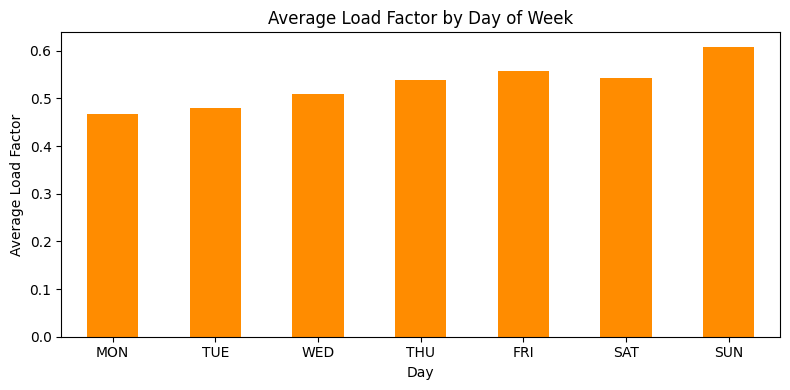

In [ ]:
day_order = ["MON","TUE","WED","THU","FRI","SAT","SUN"]
day_avg = df.groupby("Day Of Week (Short)")["Max Load"].mean().reindex(day_order)

day_avg.plot(kind="bar", figsize=(8,4), title="Average Load Factor by Day of Week", color="darkorange")
plt.ylabel("Average Load Factor")
plt.xlabel("Day")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("day_of_week_load.png", dpi=150)
plt.show()

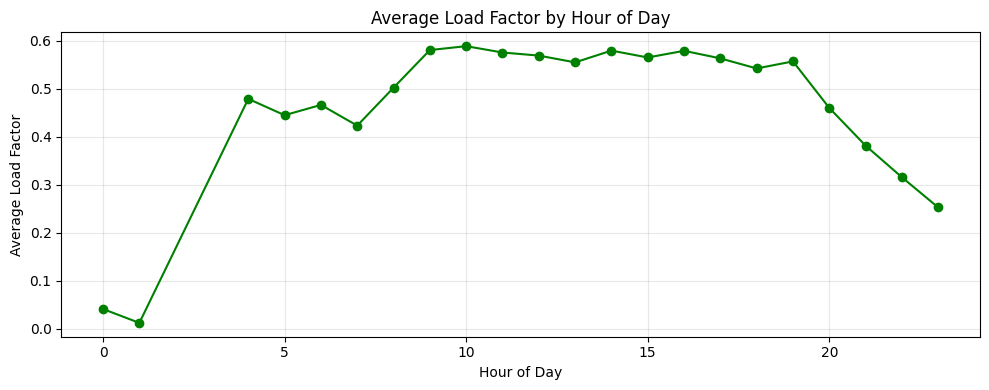

In [ ]:
hour_avg = df.groupby("Service Departure Hour")["Max Load"].mean().sort_index()

hour_avg.plot(kind="line", marker="o", figsize=(10,4), title="Average Load Factor by Hour of Day", color="green")
plt.ylabel("Average Load Factor")
plt.xlabel("Hour of Day")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("hour_of_day_load.png", dpi=150)
plt.show()

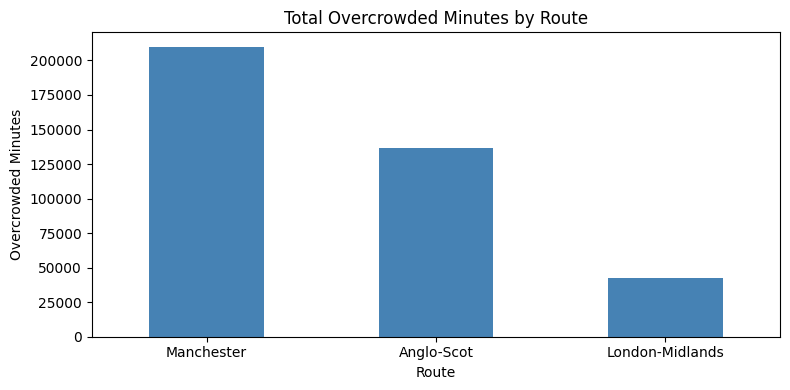

In [ ]:
route_summary["total_overcrowded_minutes"].sort_values(ascending=False).plot(
    kind="bar", figsize=(8,4), title="Total Overcrowded Minutes by Route", color="steelblue"
)
plt.ylabel("Overcrowded Minutes")
plt.xlabel("Route")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("route_overcrowding.png", dpi=150)
plt.show()